# Skinny HW3: one-feature shaft health classifier

Run from the `hw3` directory. Class labels are 0 = healthy, 1 = unbalance level 1, and 2 = unbalance level 2.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.fft import rfft, rfftfreq
from scipy.stats import kurtosis, skew
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


## Load signals and extract the original features

In [2]:
def load_signal(path):
    return np.loadtxt(path, skiprows=5)

healthy_files = sorted(Path("training-data/healthy").glob("*.txt"))
unbalance_1_files = sorted(Path("training-data/faulty/unbalance-1").glob("*.txt"))
unbalance_2_files = sorted(Path("training-data/faulty/unbalance-2").glob("*.txt"))
test_files = sorted(Path("testing-data").glob("*.txt"))

healthy_signals = [load_signal(path) for path in healthy_files]
unbalance_1_signals = [load_signal(path) for path in unbalance_1_files]
unbalance_2_signals = [load_signal(path) for path in unbalance_2_files]
test_signals = [load_signal(path) for path in test_files]

print("Training signals:", len(healthy_signals), "healthy,", len(unbalance_1_signals), "level 1,", len(unbalance_2_signals), "level 2")
print("Test signals:", len(test_signals))
print("Samples in first signal:", len(healthy_signals[0]))


Training signals: 20 healthy, 20 level 1, 20 level 2
Test signals: 30
Samples in first signal: 38400


In [3]:
SAMPLING_RATE = 2560  # Hz


In [4]:
SHAFT_FREQUENCY = 20  # Hz; 1X shaft rotation
HARMONIC_HALF_WIDTH = 0.5  # Hz


def harmonic_peak(frequencies, amplitudes, center):
    in_band = (frequencies >= center - HARMONIC_HALF_WIDTH) & (frequencies <= center + HARMONIC_HALF_WIDTH)
    return amplitudes[in_band].max()


def extract_features(signal):
    rms = np.sqrt(np.mean(signal**2))
    frequencies = rfftfreq(len(signal), d=1 / SAMPLING_RATE)
    amplitudes = 2 * np.abs(rfft(signal)) / len(signal)

    features = {
        "RMS": rms,
        "Peak-to-peak": np.ptp(signal),
        "Standard deviation": np.std(signal),
        "Kurtosis": kurtosis(signal, fisher=False),
        "Skewness": skew(signal),
        "Crest factor": np.max(np.abs(signal)) / rms,
    }

    for harmonic in range(1, 5):
        peak = harmonic_peak(frequencies, amplitudes, harmonic * SHAFT_FREQUENCY)
        features[f"{harmonic}X amplitude"] = peak
        features[f"{harmonic}X amplitude / RMS"] = peak / rms

    return features


healthy_features = pd.DataFrame([extract_features(signal) for signal in healthy_signals])
unbalance_1_features = pd.DataFrame([extract_features(signal) for signal in unbalance_1_signals])
unbalance_2_features = pd.DataFrame([extract_features(signal) for signal in unbalance_2_signals])
test_features = pd.DataFrame([extract_features(signal) for signal in test_signals])

training_features = pd.concat(
    [healthy_features, unbalance_1_features, unbalance_2_features], ignore_index=True
)
# Class labels: 0 = healthy, 1 = unbalance level 1, 2 = unbalance level 2.
training_labels = ([0] * len(healthy_signals)
                   + [1] * len(unbalance_1_signals)
                   + [2] * len(unbalance_2_signals))

print("Training features:", training_features.shape)
print("Test features:", test_features.shape)
display(training_features.head())


Training features: (60, 14)
Test features: (30, 14)


,RMS,Peak-to-peak,Standard deviation,Kurtosis,Skewness,Crest factor,1X amplitude,1X amplitude / RMS,2X amplitude,2X amplitude / RMS,3X amplitude,3X amplitude / RMS,4X amplitude,4X amplitude / RMS
0,0.066409,0.613653,0.066409,3.587488,-0.121979,4.743422,0.000062,0.000936,0.000579,0.008716,0.000205,0.003091,0.000038,0.000577
1,0.092479,0.688554,0.092479,2.938551,-0.062677,3.865084,0.000069,0.000743,0.000502,0.005431,0.000206,0.002231,0.000049,0.000526
2,0.070198,0.634557,0.070198,3.317284,0.044630,4.938712,0.000064,0.000910,0.000678,0.009664,0.000136,0.001932,0.000055,0.000782
3,0.076684,0.691687,0.076684,3.576105,-0.264599,5.104268,0.000075,0.000978,0.000661,0.008623,0.000139,0.001813,0.000062,0.000811
4,0.073982,0.837318,0.073979,4.483103,-0.248775,6.537908,0.000094,0.001271,0.000728,0.009845,0.000183,0.002472,0.000058,0.000778


## Rank features by the three-class Fisher criterion

For each feature, compare the weighted spread of the three class means with the spread within classes. This ranks individual features using all three classes and only the training data.

In [5]:
class_groups = list(training_features.groupby(training_labels))
overall_mean = training_features.mean()

between_class = sum(
    len(group) * (group.mean() - overall_mean) ** 2
    for _, group in class_groups
)
within_class = sum(
    ((group - group.mean()) ** 2).sum()
    for _, group in class_groups
)

fisher_scores = (between_class / within_class).sort_values(ascending=False)
fisher_table = fisher_scores.rename("Fisher score").to_frame()
display(fisher_table)


,Fisher score
1X amplitude,51.329290
1X amplitude / RMS,24.479591
2X amplitude,4.528073
2X amplitude / RMS,3.602787
3X amplitude,0.511013
RMS,0.229602
Standard deviation,0.229531
3X amplitude / RMS,0.117967
4X amplitude / RMS,0.090963
4X amplitude,0.067844


Standardize the selected feature using the training data, then apply the same scaling to the test data. ## Fit a one-feature, one-versus-one SVC

Use the original notebook’s linear kernel and C=1. `SVC` trains pairwise classifiers for multiclass problems; `decision_function_shape="ovo"` also exposes pairwise decision scores.

In [6]:
best_feature = fisher_scores.index[0]
scaler = StandardScaler()
X_train = scaler.fit_transform(training_features[[best_feature]])
X_test = scaler.transform(test_features[[best_feature]])

svm_model = SVC(kernel="linear", C=1.0, decision_function_shape="ovo")
svm_model.fit(X_train, training_labels)
test_predictions = svm_model.predict(X_test)
print("Best feature:", best_feature)
print("Fisher score:", fisher_scores.iloc[0])


Best feature: 1X amplitude
Fisher score: 51.32929005108123


## One-dimensional decision regions

The colored band shows the predicted class across the feature axis. Circles show training labels; X markers show test predictions. Vertical offsets only separate overlapping points and have no model meaning.

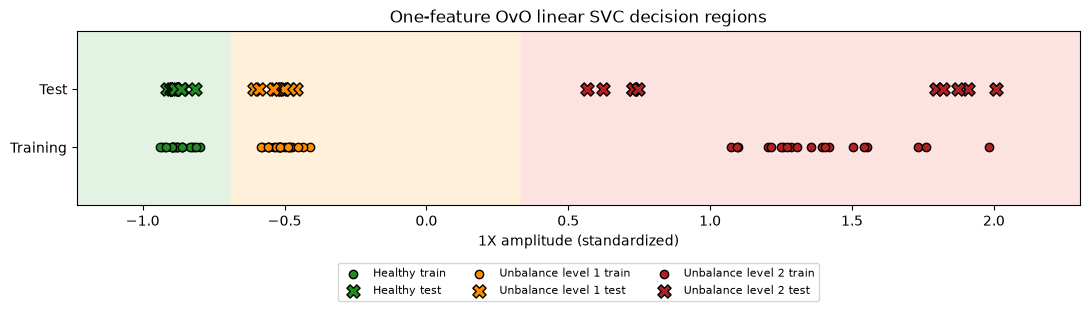

In [7]:
class_info = [(0, "Healthy", "forestgreen", "#e3f3e3"),
              (1, "Unbalance level 1", "darkorange", "#fff0d9"),
              (2, "Unbalance level 2", "firebrick", "#fde2e2")]
all_values = np.concatenate((X_train[:, 0], X_test[:, 0]))
span = np.ptp(all_values)
padding = 0.1 * span if span else 1.0
grid = np.linspace(all_values.min() - padding, all_values.max() + padding, 2000)
regions = svm_model.predict(grid.reshape(-1, 1))

fig, ax = plt.subplots(figsize=(11, 3.5))
for class_number, class_name, color, background in class_info:
    ax.fill_between(grid, -0.4, 1.4, where=regions == class_number,
                    color=background, step="mid")
    train_mask = np.asarray(training_labels) == class_number
    test_mask = test_predictions == class_number
    ax.scatter(X_train[train_mask, 0], np.full(train_mask.sum(), 0.2),
               color=color, edgecolor="black", s=36, marker="o", label=f"{class_name} train")
    ax.scatter(X_test[test_mask, 0], np.full(test_mask.sum(), 0.8),
               color=color, edgecolor="black", s=90, marker="X", label=f"{class_name} test")
ax.set(xlim=(grid[0], grid[-1]), ylim=(-0.4, 1.4),
       yticks=[0.2, 0.8], yticklabels=["Training", "Test"],
       xlabel=f"{best_feature} (standardized)", title="One-feature OvO linear SVC decision regions")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.3), ncol=3, fontsize=8)
fig.tight_layout()
plt.show()


## Test confusion matrix

As in `hw3.ipynb`, the sorted test filenames match the assignment’s three groups of ten. Assign test labels only after predictions. Rows are actual classes and columns are predicted classes.

Test accuracy: 100.0% (30/30 correct)


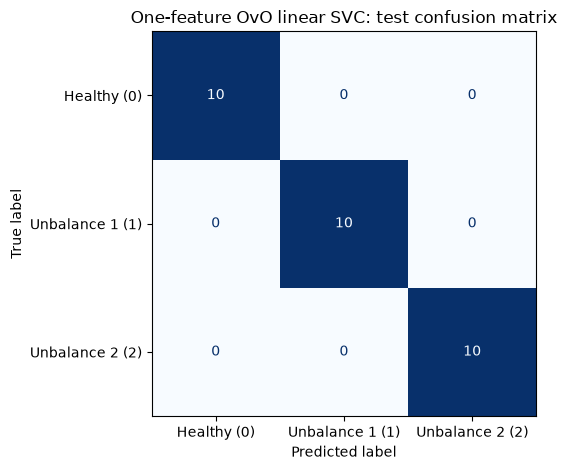

In [8]:
test_labels = np.array([0] * 10 + [1] * 10 + [2] * 10)
assert len(test_labels) == len(test_files)
confusion = confusion_matrix(test_labels, test_predictions, labels=[0, 1, 2])
accuracy = accuracy_score(test_labels, test_predictions)
print(f"Test accuracy: {accuracy:.1%} ({np.trace(confusion)}/{len(test_labels)} correct)")
ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=["Healthy (0)", "Unbalance 1 (1)", "Unbalance 2 (2)"],
).plot(cmap="Blues", colorbar=False)
plt.title("One-feature OvO linear SVC: test confusion matrix")
plt.tight_layout()
plt.show()
